In [28]:
import os 
import numpy as np
import matplotlib.pyplot as plt
dataset_path = "../dataset/dataset0420" 

数量统计

InLane: 812
ChangingLaneLeft: 107
ChangingLaneRight: 110
ChangingTurnLeft: 28
ChangingTurnRight: 41
ChangingStop: 6
Avoidance: 10
RidingLane: 7
StopAndWait: 54
Starting: 17
GoStraight: 180
TurnLeft: 52
TurnRight: 67
UTurn: 6
DriveIn: 7
DriveOut: 3
DriveIn: 25
DriveOut: 26
Driving: 35
19 1593


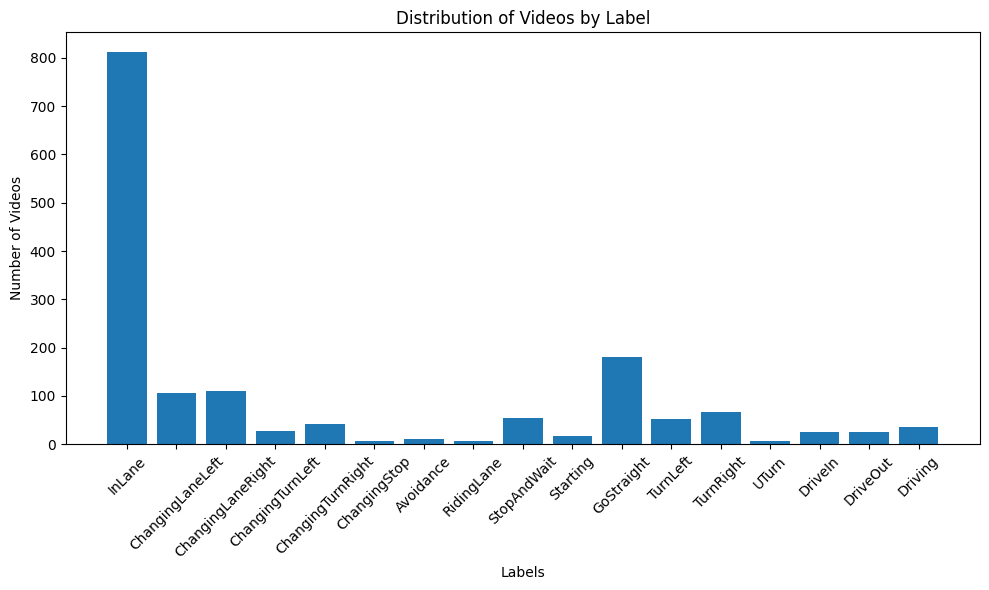

In [29]:
def plt_hist(label_names, nums):
    
    # 绘制直方图
    plt.figure(figsize=(10, 6))
    plt.bar(label_names, nums)
    plt.xlabel('Labels')
    plt.ylabel('Number of Videos')
    plt.title('Distribution of Videos by Label')
    plt.xticks(rotation=45)  # 旋转x轴标签，以便更好地显示
    plt.tight_layout()  # 调整布局
    plt.show()  # 显示直方图


# 初始化列表
label_names = []
nums = []

# 遍历数据集路径下的所有目录
for video_dir in os.listdir(dataset_path):
    # 检查是否是目录
    if not os.path.isdir(os.path.join(dataset_path, video_dir)):
        continue
    # 获取标签名称
    label_name = video_dir.split("_")[1]
    # 获取每个标签下的视频数量
    num = len(os.listdir(os.path.join(dataset_path, video_dir)))
    
    # 添加到列表中
    label_names.append(label_name)
    nums.append(num)
    print(f"{label_name}: {num}")

print(len(label_names), sum(nums))
# 调用函数绘制直方图
plt_hist(label_names, nums)

统计帧数分布

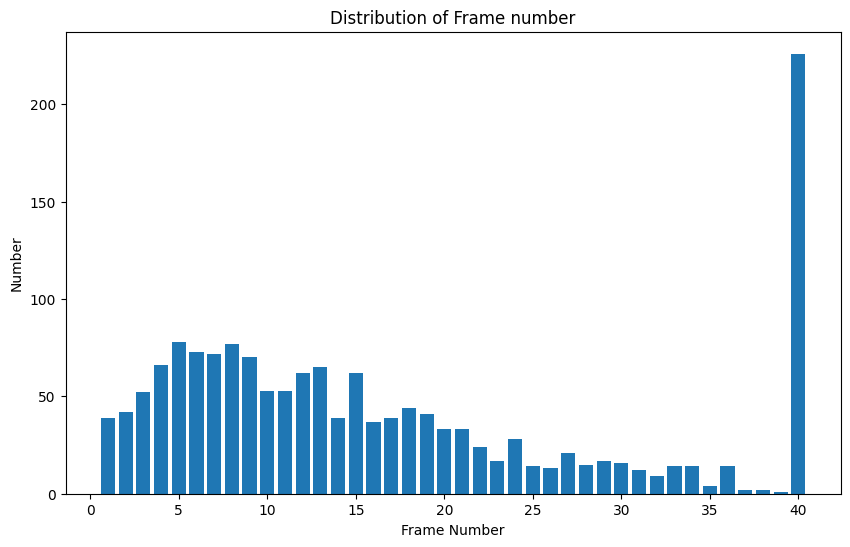

In [30]:
import json
from collections import defaultdict

video_info_path = "/data/others/ChangeLineRecognition/dataset/dataset0420/video_info.json"
with open(video_info_path, 'r') as file:
    data = json.load(file)

frame_counts = defaultdict(lambda: 0)
for video_path, info in data.items():
    label = info['label']
    frame_count = info['frame_num']
    label_name = info['label_name']

    frame_counts[frame_count] += 1

plt.figure(figsize=(10, 6))
plt.bar(frame_counts.keys(), [val for key, val in frame_counts.items()])
plt.xlabel('Frame Number')
plt.ylabel('Number')
plt.title('Distribution of Frame number')
plt.show()


展示不同label的数据

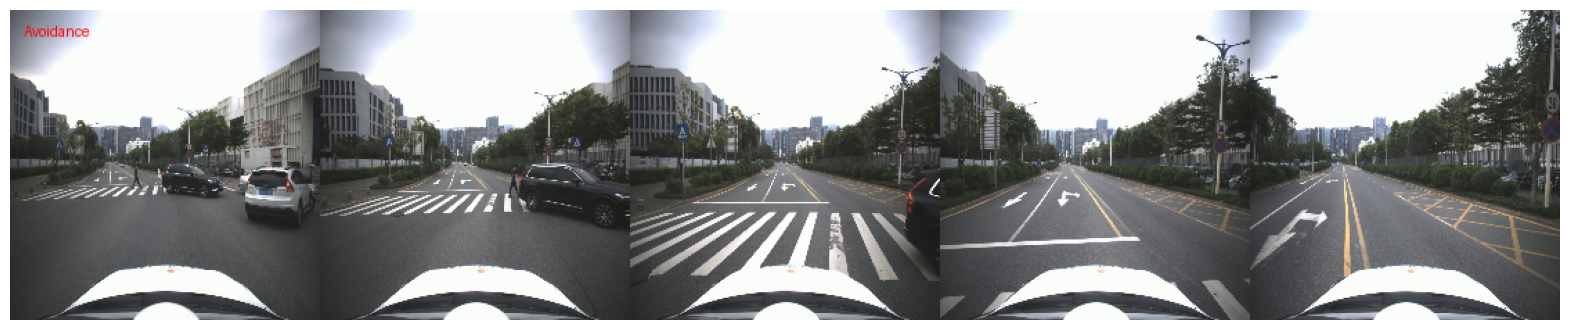

In [31]:
from PIL import Image, ImageDraw, ImageFont
import cv2
import matplotlib.pyplot as plt

def select_and_visualize_frames(video_path, num_frames=5, title="Selected Frames"):
    # 打开视频文件
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    interval = max(total_frames // num_frames, 1)  # 计算间隔

    frames = []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # 每隔 interval 帧选取一帧
        if frame_count % interval == 0 and len(frames) < num_frames:
            # 转换颜色格式从 BGR 到 RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Resize frame to 224x224
            frame = cv2.resize(frame, (224, 224))
            frames.append(frame)
        
        frame_count += 1

    cap.release()

    if not frames:
        print("Error: No frames were selected.")
        return

    # 计算合并图片的尺寸
    frame_height, frame_width, _ = frames[0].shape
    combined_image_height = frame_height
    combined_image_width = frame_width * len(frames)

    # 创建一个空白图像来合并所有选定的帧
    combined_image = Image.new('RGB', (combined_image_width, combined_image_height))

    # 将所有选定的帧合并到一个图像上
    for i, frame in enumerate(frames):
        img = Image.fromarray(frame)
        combined_image.paste(img, (i * frame_width, 0))

    # 添加标题
    draw = ImageDraw.Draw(combined_image)
    
    # 使用 TrueType 字体，并指定大小和加粗样式
    try:
        font = ImageFont.truetype("arial.ttf", 320)  # 加大字体大小
    except IOError:
        font = ImageFont.load_default()

    draw.text((10, 10), title, fill="red", font=font)

    # 创建 plt 对象
    fig, ax = plt.subplots(figsize=(20, 10))
    ax.imshow(combined_image)
    ax.axis('off')

    plt.show()



figs = []
select_label = set()
for video_path, info in data.items():
    label = info['label']
    frame_count = info['frame_num']
    label_name = info['label_name']
    if frame_count < 10:
        continue
    if label_name in select_label:
        continue
    if "Avoidance" != label_name:
        continue
    select_label.add(label_name)
    select_and_visualize_frames(video_path, 5, title=label_name)
    break



模型分析

In [14]:
import torch
from  model import CNNModel
from datasets import ImageLoader
from dataset import *
import numpy as np

def get_transform():
    normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    spatial_transform = [
        Resize(224),
        CenterCrop(224),
        ToTensor()
    ]
    spatial_transform.extend([ScaleValue(1), normalize])
    spatial_transform = Compose(spatial_transform)

    return spatial_transform

model_path = "ckpts/2024-06-10-19-05_resnet18_baseline/model_100.pth"
model = CNNModel(backbone="resnet18", class_num=7)
model.load_state_dict(torch.load(model_path, map_location='cpu')['net'], strict=True)



/home/laolingjie/.virtualenvs/py312/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/laolingjie/.virtualenvs/py312/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [58]:
loader =  ImageLoader()
with open("../dataset/dataset0420/test.txt", 'r') as f:
    for line in f:
        video_path = line.split(" ")[0]
        label = line.split(" ")[1]
        if label != '5':
            continue
        video_frame = loader(video_path, 5)
        spatial_transform = get_transform()
        clip = [spatial_transform(img) for img in video_frame]
        clip = torch.stack(clip, 0).unsqueeze(0)
        output = model(clip)
        if torch.argmax(output).item() == 1:
            print(video_path)
            print(torch.softmax(output, 1))


In [56]:
torch.softmax(output, 1)

tensor([[9.2971e-01, 4.3254e-03, 7.0134e-04, 1.2304e-04, 1.4802e-02, 1.0034e-02,
         4.0302e-02]], grad_fn=<SoftmaxBackward0>)

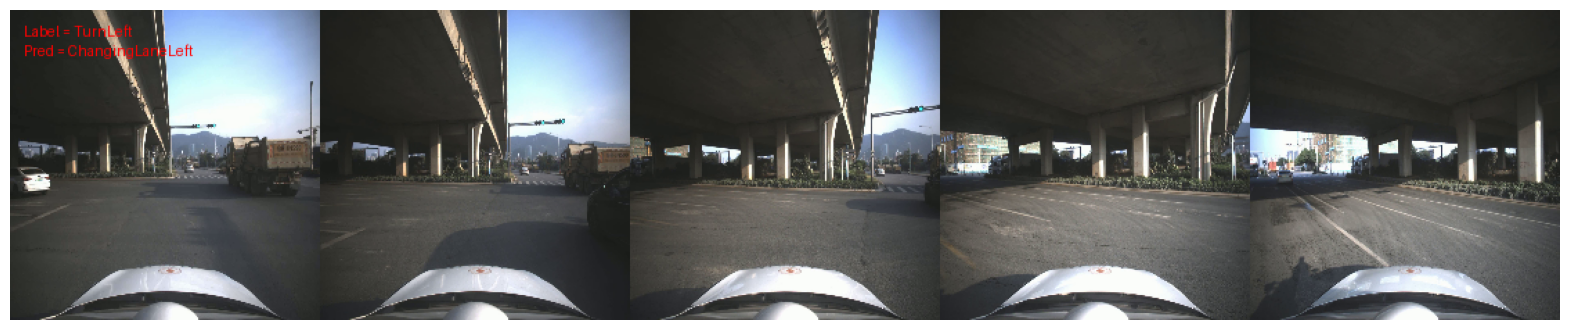

In [50]:
select_and_visualize_frames("/data/others/ChangeLineRecognition/dataset/dataset0420/11_TurnLeft/scene-001062+5+2.5_TurnLeft.avi", 5, title="Label = TurnLeft\nPred = ChangingLaneLeft")

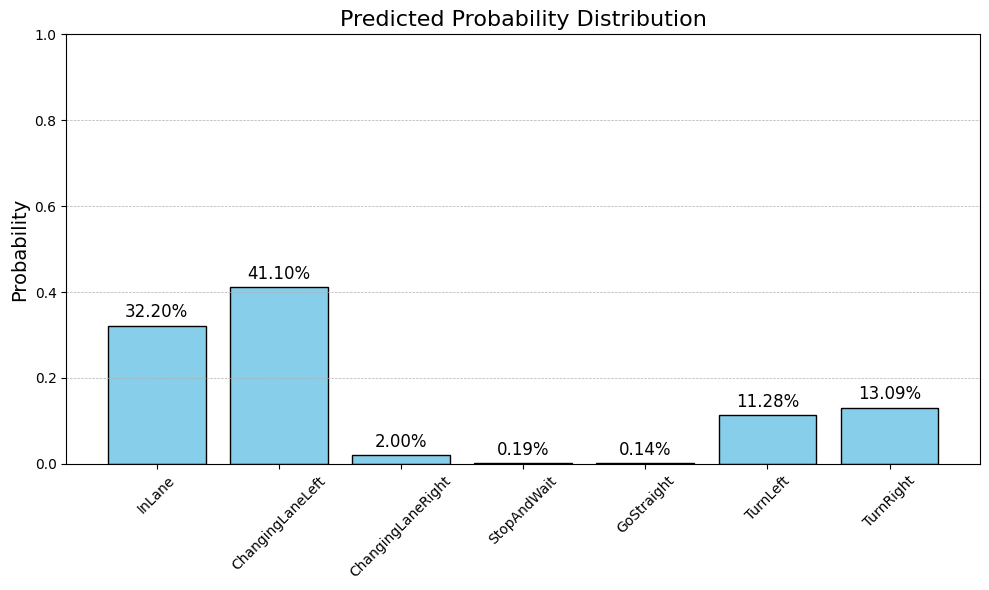

In [46]:
# 预测概率
preds = [0.3220, 0.4110, 0.0200, 0.0019, 0.0014, 0.1128, 0.1309]

# 类别标签
labels = ["InLane", "ChangingLaneLeft", "ChangingLaneRight", "StopAndWait", "GoStraight", "TurnLeft", "TurnRight"]

# 创建一个图形和子图
plt.figure(figsize=(10, 6))

# 绘制柱状图
bars = plt.bar(labels, preds, color='skyblue', edgecolor='k')

# 添加标题和标签
plt.title('Predicted Probability Distribution', fontsize=16)
plt.ylabel('Probability', fontsize=14)

# 添加概率值到每个柱子上方
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontsize=12)

# 美化图形
plt.ylim(0, 1)  # 确保 y 轴范围为 0 到 1
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

# 显示图形
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame()
df.value_counts